# Polar Verity Sense Offline PPI JSONL EDA Tutorial

Цей notebook допомагає дослідити `chunks.jsonl` з Polar Verity Sense offline PPI stream:

- прочитати JSONL raw chunks;
- розгорнути `payload.samples[]` у sample-level таблицю;
- пояснити кожне поле;
- перевірити timestamps, gaps, duplicates, monotonicity;
- оцінити якість PPI через `blockerBit`, `skinContactStatus`, `ppErrorEstimate`;
- побудувати графіки для data preparation та майбутніх ML/sleep-feature задач;
- підготувати базові window features.

> Важливо: raw JSONL не змінюємо. Усі pretty/processed таблиці створюються окремо.


In [3]:
# === 0. Imports & global settings ===

from __future__ import annotations

import json
import math
import os
from pathlib import Path
from typing import Any, Dict, Iterable, List, Optional, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 160)
pd.set_option("display.max_colwidth", 120)

# Matplotlib basic readable defaults.
# No custom colors: keeps charts portable and notebook-friendly.
plt.rcParams["figure.figsize"] = (14, 5)
plt.rcParams["axes.grid"] = True

print("pandas:", pd.__version__)


pandas: 3.0.2


## 1. Вкажи шлях до JSONL

Notebook очікує файл, де кожен рядок — це один uploaded chunk, а всередині є `payload.samples[]`.

Якщо запускаєш notebook з кореня repo, дефолтний шлях нижче має підійти. Якщо ні — зміни `JSONL_PATH`.


In [4]:
# === 1. Input path ===

JSONL_PATH = Path(
    "notebooks/data_cache/session_id=a3b4f7a4-c810-4e7a-8152-e9a05dd32b1e/"
    "data/wearable/raw/user_id=2/source=polar_verity_sense/date=2026-05-06/"
    "session_id=a3b4f7a4-c810-4e7a-8152-e9a05dd32b1e/streams/ppi/chunks.jsonl"
)

# Optional fallback: if you keep this notebook near another location, paste absolute path here.
# JSONL_PATH = Path("/absolute/path/to/chunks.jsonl")

print("JSONL_PATH:", JSONL_PATH)
print("Exists:", JSONL_PATH.exists())

if not JSONL_PATH.exists():
    raise FileNotFoundError(
        f"File not found: {JSONL_PATH}\n"
        "Update JSONL_PATH to the actual chunks.jsonl location."
    )


JSONL_PATH: notebooks/data_cache/session_id=a3b4f7a4-c810-4e7a-8152-e9a05dd32b1e/data/wearable/raw/user_id=2/source=polar_verity_sense/date=2026-05-06/session_id=a3b4f7a4-c810-4e7a-8152-e9a05dd32b1e/streams/ppi/chunks.jsonl
Exists: True


## 2. Що означають поля

### Chunk-level fields

| Field | Meaning | Для чого потрібно |
|---|---|---|
| `source.vendor` | vendor девайса, наприклад `polar` | routing/adapter lineage |
| `source.device_model` | модель, наприклад `verity_sense` | device-specific parsing/quality rules |
| `source.device_id` | ID фізичного сенсора | розділення між пристроями |
| `stream_id` | стабільний stream у межах session | traceability |
| `session_id` | recording/session identifier | групування даних |
| `collection.mode` | `offline_recording` | важливо для timestamp interpretation |
| `sequence` | порядок chunks | перевірка missing/duplicate chunks |
| `payload.source` | SDK/adapter source label | debug lineage |
| `payload.samples` | масив PPI samples | основні sample-level дані |

### Sample-level fields

| Field | Meaning | Practical interpretation |
|---|---|---|
| `timeStamp` | device timestamp, ймовірно ns/device-time reference | основа для ordering/gap detection |
| `ppInMs` | pulse-to-pulse interval у ms | аналог RR-like interval для HRV features |
| `hr` | HR від SDK у sample, може бути `0` при low-quality/offline cases | не завжди надійний |
| `ppErrorEstimate` | оцінка помилки PPI у ms | quality / confidence |
| `blockerBit` | quality blocker flag | якщо `1`, sample треба маркувати як suspicious/invalid |
| `skinContactSupported` | чи підтримується contact flag | metadata/quality support |
| `skinContactStatus` | contact status | якщо contact lost — PPI не довіряти |

> Для ML підготовки важливо не просто видалити погані samples, а зберегти quality flags як features: valid ratio, blocker ratio, contact-loss ratio, ppError stats, gap ratio.


In [5]:
# === 2. JSONL loading helpers ===

def read_jsonl_chunks(path: Path) -> List[Dict[str, Any]]:
    """Read JSONL file where each line is a JSON object / upload chunk."""
    chunks: List[Dict[str, Any]] = []
    bad_lines: List[Tuple[int, str]] = []

    with path.open("r", encoding="utf-8") as f:
        for line_no, line in enumerate(f, start=1):
            raw = line.strip()
            if not raw:
                continue
            try:
                chunks.append(json.loads(raw))
            except json.JSONDecodeError as e:
                bad_lines.append((line_no, str(e)))

    if bad_lines:
        preview = bad_lines[:5]
        raise ValueError(f"Found {len(bad_lines)} malformed JSONL lines. First errors: {preview}")

    return chunks


chunks = read_jsonl_chunks(JSONL_PATH)

print("Chunks:", len(chunks))
print("First chunk keys:", list(chunks[0].keys()) if chunks else None)
print("First chunk sample count:", len(chunks[0].get("payload", {}).get("samples", [])) if chunks else None)


Chunks: 1
First chunk keys: ['source', 'stream_id', 'session_id', 'collection', 'sequence', 'payload', 'chunk_id', 'stream_type', 'time', 'transport', 'schema_version', 'user_id', 'server']
First chunk sample count: 23660


In [6]:
# === 3. Inspect chunk-level metadata ===

chunk_rows = []
for i, ch in enumerate(chunks):
    payload = ch.get("payload") or {}
    source = ch.get("source") or {}
    collection = ch.get("collection") or {}
    transport = ch.get("transport") or {}
    time_obj = ch.get("time") or {}

    chunk_rows.append({
        "jsonl_line_index": i,
        "sequence": ch.get("sequence"),
        "session_id": ch.get("session_id"),
        "stream_id": ch.get("stream_id"),
        "stream_type": ch.get("stream_type"),
        "vendor": source.get("vendor"),
        "device_model": source.get("device_model"),
        "device_id": source.get("device_id"),
        "collection_mode": collection.get("mode"),
        "payload_source": payload.get("source"),
        "payload_schema": transport.get("payload_schema"),
        "payload_version": transport.get("payload_version"),
        "first_sample_received_at_collector": time_obj.get("first_sample_received_at_collector"),
        "uploaded_at_collector": time_obj.get("uploaded_at_collector"),
        "sample_count": len(payload.get("samples") or []),
    })

chunks_df = pd.DataFrame(chunk_rows)
display(chunks_df.head(20))
display(chunks_df.describe(include="all").T)


,jsonl_line_index,sequence,session_id,stream_id,stream_type,vendor,device_model,device_id,collection_mode,payload_source,payload_schema,payload_version,first_sample_received_at_collector,uploaded_at_collector,sample_count
0,0,1,a3b4f7a4-c810-4e7a-8152-e9a05dd32b1e,stream-offline-ppi-a3b4f7a4-c810-4e7a-8152-e9a05dd32b1e,ppi,polar,verity_sense,06EDBA31,offline_recording,polar_verity_sense_offline,polar.offline.ppi,1.0,2026-05-06T07:13:52.121Z,2026-05-06T07:14:34.533Z,23660


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
jsonl_line_index,1.0,NaN,NaN,NaN,0.0,NaN,0.0,0.0,0.0,0.0,0.0
sequence,1.0,NaN,NaN,NaN,1.0,NaN,1.0,1.0,1.0,1.0,1.0
session_id,1,1,a3b4f7a4-c810-4e7a-8152-e9a05dd32b1e,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
stream_id,1,1,stream-offline-ppi-a3b4f7a4-c810-4e7a-8152-e9a05dd32b1e,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
stream_type,1,1,ppi,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
vendor,1,1,polar,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
device_model,1,1,verity_sense,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
device_id,1,1,06EDBA31,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
collection_mode,1,1,offline_recording,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
payload_source,1,1,polar_verity_sense_offline,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [7]:
# === 4. Flatten payload.samples[] into sample-level DataFrame ===

sample_rows = []

for chunk_idx, ch in enumerate(chunks):
    payload = ch.get("payload") or {}
    source = ch.get("source") or {}
    collection = ch.get("collection") or {}
    samples = payload.get("samples") or []

    for sample_idx, s in enumerate(samples):
        row = {
            # lineage
            "chunk_index": chunk_idx,
            "sample_index_in_chunk": sample_idx,
            "sequence": ch.get("sequence"),
            "session_id": ch.get("session_id"),
            "stream_id": ch.get("stream_id"),
            "vendor": source.get("vendor"),
            "device_model": source.get("device_model"),
            "device_id": source.get("device_id"),
            "collection_mode": collection.get("mode"),
            "payload_source": payload.get("source"),

            # sample fields
            "timeStamp": s.get("timeStamp"),
            "hr": s.get("hr"),
            "ppErrorEstimate": s.get("ppErrorEstimate"),
            "skinContactSupported": s.get("skinContactSupported"),
            "ppInMs": s.get("ppInMs"),
            "skinContactStatus": s.get("skinContactStatus"),
            "blockerBit": s.get("blockerBit"),
        }
        sample_rows.append(row)

df = pd.DataFrame(sample_rows)

# Coerce important columns to numeric
numeric_cols = [
    "sequence", "sample_index_in_chunk", "timeStamp", "hr", "ppErrorEstimate",
    "skinContactSupported", "ppInMs", "skinContactStatus", "blockerBit"
]
for col in numeric_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

print("Samples:", len(df))
display(df.head())
display(df.tail())
display(df.dtypes)


Samples: 23660


,chunk_index,sample_index_in_chunk,sequence,session_id,stream_id,vendor,device_model,device_id,collection_mode,payload_source,timeStamp,hr,ppErrorEstimate,skinContactSupported,ppInMs,skinContactStatus,blockerBit
0,0,0,1,a3b4f7a4-c810-4e7a-8152-e9a05dd32b1e,stream-offline-ppi-a3b4f7a4-c810-4e7a-8152-e9a05dd32b1e,polar,verity_sense,06EDBA31,offline_recording,polar_verity_sense_offline,18014354808481984,0,30,1,393,1,1
1,0,1,1,a3b4f7a4-c810-4e7a-8152-e9a05dd32b1e,stream-offline-ppi-a3b4f7a4-c810-4e7a-8152-e9a05dd32b1e,polar,verity_sense,06EDBA31,offline_recording,polar_verity_sense_offline,18014355991481984,0,30,1,1183,1,1
2,0,2,1,a3b4f7a4-c810-4e7a-8152-e9a05dd32b1e,stream-offline-ppi-a3b4f7a4-c810-4e7a-8152-e9a05dd32b1e,polar,verity_sense,06EDBA31,offline_recording,polar_verity_sense_offline,18014356988481984,0,30,1,997,1,1
3,0,3,1,a3b4f7a4-c810-4e7a-8152-e9a05dd32b1e,stream-offline-ppi-a3b4f7a4-c810-4e7a-8152-e9a05dd32b1e,polar,verity_sense,06EDBA31,offline_recording,polar_verity_sense_offline,18014357950481984,0,30,1,962,1,0
4,0,4,1,a3b4f7a4-c810-4e7a-8152-e9a05dd32b1e,stream-offline-ppi-a3b4f7a4-c810-4e7a-8152-e9a05dd32b1e,polar,verity_sense,06EDBA31,offline_recording,polar_verity_sense_offline,18014358945481984,0,30,1,995,1,1


,chunk_index,sample_index_in_chunk,sequence,session_id,stream_id,vendor,device_model,device_id,collection_mode,payload_source,timeStamp,hr,ppErrorEstimate,skinContactSupported,ppInMs,skinContactStatus,blockerBit
23655,0,23655,1,a3b4f7a4-c810-4e7a-8152-e9a05dd32b1e,stream-offline-ppi-a3b4f7a4-c810-4e7a-8152-e9a05dd32b1e,polar,verity_sense,06EDBA31,offline_recording,polar_verity_sense_offline,0,44,30,1,938,1,1
23656,0,23656,1,a3b4f7a4-c810-4e7a-8152-e9a05dd32b1e,stream-offline-ppi-a3b4f7a4-c810-4e7a-8152-e9a05dd32b1e,polar,verity_sense,06EDBA31,offline_recording,polar_verity_sense_offline,0,44,35,1,1063,1,1
23657,0,23657,1,a3b4f7a4-c810-4e7a-8152-e9a05dd32b1e,stream-offline-ppi-a3b4f7a4-c810-4e7a-8152-e9a05dd32b1e,polar,verity_sense,06EDBA31,offline_recording,polar_verity_sense_offline,0,44,38,1,1001,1,1
23658,0,23658,1,a3b4f7a4-c810-4e7a-8152-e9a05dd32b1e,stream-offline-ppi-a3b4f7a4-c810-4e7a-8152-e9a05dd32b1e,polar,verity_sense,06EDBA31,offline_recording,polar_verity_sense_offline,0,44,367,1,1934,1,1
23659,0,23659,1,a3b4f7a4-c810-4e7a-8152-e9a05dd32b1e,stream-offline-ppi-a3b4f7a4-c810-4e7a-8152-e9a05dd32b1e,polar,verity_sense,06EDBA31,offline_recording,polar_verity_sense_offline,0,44,42,1,1625,1,1


chunk_index              int64
sample_index_in_chunk    int64
sequence                 int64
session_id                 str
stream_id                  str
vendor                     str
device_model               str
device_id                  str
collection_mode            str
payload_source             str
timeStamp                int64
hr                       int64
ppErrorEstimate          int64
skinContactSupported     int64
ppInMs                   int64
skinContactStatus        int64
blockerBit               int64
dtype: object

## 3. Базова якість даних

Тут перевіряємо:

- чи є missing values;
- чи однакова metadata;
- чи `sequence` не має дірок;
- чи `timeStamp` монотонний;
- чи є duplicate timestamps;
- які діапазони значень для `ppInMs`, `hr`, `ppErrorEstimate`.


In [8]:
# === 5. Missing values and unique metadata ===

missing = df.isna().sum().sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(3) if len(df) else missing

missing_df = pd.DataFrame({
    "missing_count": missing,
    "missing_pct": missing_pct,
})
display(missing_df)

meta_cols = ["session_id", "stream_id", "vendor", "device_model", "device_id", "collection_mode", "payload_source"]
for col in meta_cols:
    if col in df.columns:
        print(f"{col}: {df[col].nunique(dropna=False)} unique")
        display(df[col].value_counts(dropna=False).head(20))


,missing_count,missing_pct
chunk_index,0,0.0
payload_source,0,0.0
skinContactStatus,0,0.0
ppInMs,0,0.0
skinContactSupported,0,0.0
ppErrorEstimate,0,0.0
hr,0,0.0
timeStamp,0,0.0
collection_mode,0,0.0
sample_index_in_chunk,0,0.0


session_id: 1 unique


session_id
a3b4f7a4-c810-4e7a-8152-e9a05dd32b1e    23660
Name: count, dtype: int64

stream_id: 1 unique


stream_id
stream-offline-ppi-a3b4f7a4-c810-4e7a-8152-e9a05dd32b1e    23660
Name: count, dtype: int64

...

device_id
06EDBA31    23660
Name: count, dtype: int64

collection_mode: 1 unique


collection_mode
offline_recording    23660
Name: count, dtype: int64

payload_source: 1 unique


payload_source
polar_verity_sense_offline    23660
Name: count, dtype: int64

In [9]:
# === 6. Chunk sequence checks ===

display(chunks_df[["jsonl_line_index", "sequence", "sample_count"]].head(50))

seq = chunks_df["sequence"].dropna().astype(int).sort_values().to_numpy()
expected_seq = np.arange(seq.min(), seq.max() + 1) if len(seq) else np.array([])
missing_seq = sorted(set(expected_seq) - set(seq))
duplicate_seq = chunks_df["sequence"][chunks_df["sequence"].duplicated(keep=False)].dropna().tolist()

print("sequence min/max:", (seq.min(), seq.max()) if len(seq) else None)
print("missing sequences:", missing_seq[:50], "count:", len(missing_seq))
print("duplicate sequences count:", len(duplicate_seq))


,jsonl_line_index,sequence,sample_count
0,0,1,23660


sequence min/max: (np.int64(1), np.int64(1))
missing sequences: [] count: 0
duplicate sequences count: 0


In [10]:
# === 7. Sort samples by device timestamp and derive time deltas ===

df_sorted = df.sort_values(["timeStamp", "chunk_index", "sample_index_in_chunk"]).reset_index(drop=True).copy()

df_sorted["timestamp_diff_raw"] = df_sorted["timeStamp"].diff()

# Heuristic: Polar timestamps are commonly ns-like. Convert raw diffs to seconds if raw unit is ns.
# For offline files, absolute timestamp origin may be device-specific; relative deltas are still useful.
df_sorted["timestamp_diff_s_if_ns"] = df_sorted["timestamp_diff_raw"] / 1e9

df_sorted["is_timestamp_monotonic_non_decreasing"] = df_sorted["timestamp_diff_raw"].fillna(0) >= 0
df_sorted["is_duplicate_timestamp"] = df_sorted["timeStamp"].duplicated(keep=False)

print("Monotonic non-decreasing:", bool(df_sorted["is_timestamp_monotonic_non_decreasing"].all()))
print("Duplicate timestamps:", int(df_sorted["is_duplicate_timestamp"].sum()))
print("Negative timestamp diffs:", int((df_sorted["timestamp_diff_raw"] < 0).sum()))

display(df_sorted[["timeStamp", "timestamp_diff_raw", "timestamp_diff_s_if_ns", "ppInMs", "hr", "ppErrorEstimate", "blockerBit", "skinContactStatus"]].head(20))
display(df_sorted[["timestamp_diff_raw", "timestamp_diff_s_if_ns"]].describe(percentiles=[.01, .05, .25, .5, .75, .95, .99]).T)


Monotonic non-decreasing: True
Duplicate timestamps: 12040
Negative timestamp diffs: 0


,timeStamp,timestamp_diff_raw,timestamp_diff_s_if_ns,ppInMs,hr,ppErrorEstimate,blockerBit,skinContactStatus
0,0,NaN,NaN,953,0,26,1,1
1,0,0.0,0.0,821,0,29,1,1
2,0,0.0,0.0,877,0,30,1,1
3,0,0.0,0.0,874,0,29,0,1
4,0,0.0,0.0,867,0,453,0,1
5,0,0.0,0.0,1214,0,30,1,1
6,0,0.0,0.0,1034,0,57,1,1
7,0,0.0,0.0,1346,0,80,1,1
8,0,0.0,0.0,891,0,430,1,1
9,0,0.0,0.0,2112,0,325,1,1


,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
timestamp_diff_raw,23659.0,7.614184e+11,1.171170e+14,0.0,0.0,0.0,0.0,1000000.000,3000000.000,10000000.00,1.800000e+07,1.801434e+16
timestamp_diff_s_if_ns,23659.0,7.614184e+02,1.171170e+05,0.0,0.0,0.0,0.0,0.001,0.003,0.01,1.800000e-02,1.801434e+07


## 4. Інтерпретація timestamp gaps

Для PPI очікуваний інтервал між samples не є фіксованим, бо це event-like stream: наступний sample приходить після наступного pulse interval.

Практична перевірка:

- `ppInMs / 1000` — фізіологічний PPI interval;
- `timestamp_diff_s_if_ns` — різниця між device timestamps;
- якщо timestamp diff приблизно збігається з PPI, timestamp можна використовувати для реконструкції sample timeline;
- якщо не збігається, треба обережно ставитись до time alignment.

Notebook рахує `delta_minus_pp_s`: різниця між timestamp gap та `ppInMs`.


In [11]:
# === 8. Compare timestamp deltas with PPI duration ===

df_sorted["pp_s"] = df_sorted["ppInMs"] / 1000.0
df_sorted["delta_minus_pp_s"] = df_sorted["timestamp_diff_s_if_ns"] - df_sorted["pp_s"]

# Avoid first NaN row
cmp = df_sorted.dropna(subset=["timestamp_diff_s_if_ns", "pp_s", "delta_minus_pp_s"]).copy()

display(cmp[["timestamp_diff_s_if_ns", "pp_s", "delta_minus_pp_s"]].describe(percentiles=[.01, .05, .25, .5, .75, .95, .99]).T)

# Potential large gaps: tune threshold after looking at distributions.
GAP_THRESHOLD_S = 5.0
df_sorted["gap_gt_threshold"] = df_sorted["timestamp_diff_s_if_ns"] > GAP_THRESHOLD_S

print(f"Gaps > {GAP_THRESHOLD_S}s:", int(df_sorted["gap_gt_threshold"].sum()))
display(df_sorted[df_sorted["gap_gt_threshold"]][
    ["timeStamp", "timestamp_diff_s_if_ns", "ppInMs", "hr", "ppErrorEstimate", "blockerBit", "skinContactStatus", "sequence"]
].head(50))


,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
timestamp_diff_s_if_ns,23659.0,761.418425,117117.034416,0.000,0.00000,0.000,0.000,0.001,0.003,0.010,0.01800,1.801434e+07
pp_s,23659.0,1.279246,0.130701,0.385,0.83458,1.062,1.214,1.295,1.360,1.449,1.50642,2.563000e+00
delta_minus_pp_s,23659.0,760.139179,117117.033013,-2.561,-1.50500,-1.446,-1.358,-1.293,-1.212,-1.059,-0.83200,1.801433e+07


Gaps > 5.0s: 1


,timeStamp,timestamp_diff_s_if_ns,ppInMs,hr,ppErrorEstimate,blockerBit,skinContactStatus,sequence
7732,18014336007481984,1.801434e+07,1495,39,8,0,1,1


In [12]:
# === 9. Build relative time axis ===

# Relative time from first sample, assuming ns-like timestamp.
# This avoids claiming canonical UTC. It is only session-relative time.
first_ts = df_sorted["timeStamp"].dropna().iloc[0] if len(df_sorted["timeStamp"].dropna()) else np.nan
df_sorted["t_rel_s"] = (df_sorted["timeStamp"] - first_ts) / 1e9
df_sorted["t_rel_min"] = df_sorted["t_rel_s"] / 60.0
df_sorted["t_rel_hour"] = df_sorted["t_rel_s"] / 3600.0

duration_s = df_sorted["t_rel_s"].max() - df_sorted["t_rel_s"].min()
print("Approx relative duration:", duration_s, "seconds =", duration_s / 60, "minutes =", duration_s / 3600, "hours")
display(df_sorted[["t_rel_s", "t_rel_min", "timeStamp", "ppInMs", "hr", "ppErrorEstimate", "blockerBit", "skinContactStatus"]].head())


Approx relative duration: 18014398.509481985 seconds = 300239.9751580331 minutes = 5003.999585967218 hours


,t_rel_s,t_rel_min,timeStamp,ppInMs,hr,ppErrorEstimate,blockerBit,skinContactStatus
0,0.0,0.0,0,953,0,26,1,1
1,0.0,0.0,0,821,0,29,1,1
2,0.0,0.0,0,877,0,30,1,1
3,0.0,0.0,0,874,0,29,0,1
4,0.0,0.0,0,867,0,453,0,1


## 5. Quality labels для data preparation

Створюємо прості quality flags. Це не фінальна медична логіка, а стартова EDA-логіка:

- `valid_contact`: якщо contact status підтримується і дорівнює 1;
- `not_blocked`: `blockerBit == 0`;
- `pp_error_ok`: `ppErrorEstimate <= threshold`;
- `ppi_physio_plausible`: PPI в межах rough physiological range;
- `is_valid_candidate`: sample потенційно придатний для HRV/window features.

Пороги треба тюнити після валідації на реальних sessions.


In [13]:
# === 10. Quality flags ===

# Conservative default thresholds for EDA. Tune later based on your data and target task.
PP_MIN_MS = 300      # 200 bpm
PP_MAX_MS = 2000     # 30 bpm
PP_ERROR_MAX_MS = 30 # start permissive because sample shows 30; test sensitivity later

df_sorted["valid_contact"] = np.where(
    df_sorted["skinContactSupported"] == 1,
    df_sorted["skinContactStatus"] == 1,
    np.nan
)

df_sorted["not_blocked"] = df_sorted["blockerBit"] == 0
df_sorted["pp_error_ok"] = df_sorted["ppErrorEstimate"] <= PP_ERROR_MAX_MS
df_sorted["ppi_physio_plausible"] = df_sorted["ppInMs"].between(PP_MIN_MS, PP_MAX_MS, inclusive="both")

df_sorted["is_valid_candidate"] = (
    df_sorted["ppi_physio_plausible"].fillna(False)
    & df_sorted["not_blocked"].fillna(False)
    & df_sorted["pp_error_ok"].fillna(False)
    & (df_sorted["valid_contact"].fillna(True).astype(bool))
)

quality_cols = [
    "valid_contact", "not_blocked", "pp_error_ok", "ppi_physio_plausible", "is_valid_candidate"
]

quality_summary = pd.DataFrame({
    "true_count": [int((df_sorted[c] == True).sum()) for c in quality_cols],
    "false_count": [int((df_sorted[c] == False).sum()) for c in quality_cols],
    "nan_count": [int(df_sorted[c].isna().sum()) for c in quality_cols],
    "true_pct": [round(float((df_sorted[c] == True).mean() * 100), 3) for c in quality_cols],
}, index=quality_cols)

display(quality_summary)

display(df_sorted[["ppInMs", "hr", "ppErrorEstimate", "blockerBit", "skinContactStatus", *quality_cols]].head(20))


,true_count,false_count,nan_count,true_pct
valid_contact,23660,0,0,100.000
not_blocked,22797,863,0,96.352
pp_error_ok,23098,562,0,97.625
ppi_physio_plausible,23644,16,0,99.932
is_valid_candidate,22657,1003,0,95.761


,ppInMs,hr,ppErrorEstimate,blockerBit,skinContactStatus,valid_contact,not_blocked,pp_error_ok,ppi_physio_plausible,is_valid_candidate
0,953,0,26,1,1,1.0,False,True,True,False
1,821,0,29,1,1,1.0,False,True,True,False
2,877,0,30,1,1,1.0,False,True,True,False
3,874,0,29,0,1,1.0,True,True,True,True
4,867,0,453,0,1,1.0,True,False,True,False
5,1214,0,30,1,1,1.0,False,True,True,False
6,1034,0,57,1,1,1.0,False,False,True,False
7,1346,0,80,1,1,1.0,False,False,True,False
8,891,0,430,1,1,1.0,False,False,True,False
9,2112,0,325,1,1,1.0,False,False,False,False


In [14]:
# === 11. Value distributions ===

display(df_sorted[["ppInMs", "hr", "ppErrorEstimate", "blockerBit", "skinContactSupported", "skinContactStatus"]].describe(percentiles=[.01, .05, .25, .5, .75, .95, .99]).T)

for col in ["hr", "ppErrorEstimate", "blockerBit", "skinContactSupported", "skinContactStatus"]:
    print("\n", col)
    display(df_sorted[col].value_counts(dropna=False).sort_index().head(50))


,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
ppInMs,23660.0,1279.231910,130.715084,385.0,834.59,1062.0,1214.0,1295.0,1360.0,1449.0,1506.41,2563.0
hr,23660.0,46.664920,4.950968,0.0,40.00,41.0,44.0,46.0,49.0,53.0,60.00,81.0
ppErrorEstimate,23660.0,14.782164,43.431368,3.0,6.00,7.0,9.0,10.0,12.0,17.0,72.41,1290.0
blockerBit,23660.0,0.036475,0.187473,0.0,0.00,0.0,0.0,0.0,0.0,0.0,1.00,1.0
skinContactSupported,23660.0,1.000000,0.000000,1.0,1.00,1.0,1.0,1.0,1.0,1.0,1.00,1.0
skinContactStatus,23660.0,1.000000,0.000000,1.0,1.00,1.0,1.0,1.0,1.0,1.0,1.00,1.0



 hr


hr
0       75
30      59
31       3
38      11
39      67
40     266
41     740
42    1386
43    1837
44    2698
45    3037
46    2593
47    2158
48    1877
49    1493
50    1494
51    1232
52     900
53     648
54     260
55     222
56     161
57      51
58      30
59      48
60     137
61      29
62      23
63      15
64      13
65      10
69      17
70      21
73       6
74       6
76       7
77       6
78      11
79       6
81       7
Name: count, dtype: int64


 ppErrorEstimate


ppErrorEstimate
3        4
4       32
5      169
6      548
7     1424
8     2826
9     3716
10    3928
11    3367
12    2480
13    1684
14    1055
15     624
16     411
17     215
18     116
19      73
20      66
21      50
22      50
23      33
24      42
25      27
26      44
27      23
28      29
29      31
30      31
31      22
32      22
33      18
34      11
35      24
36      12
37      16
38       6
39       9
40      19
41      13
42      17
43       8
44       9
45      10
46       9
47       5
48       8
49      12
50       7
51       5
52       3
Name: count, dtype: int64

...

blockerBit
0    22797
1      863
Name: count, dtype: int64


 skinContactSupported


skinContactSupported
1    23660
Name: count, dtype: int64


 skinContactStatus


skinContactStatus
1    23660
Name: count, dtype: int64

## 6. Графіки для розуміння даних

Графіки нижче відповідають типовим питанням data preparation:

1. Чи є довгі gaps?
2. Чи PPI має фізіологічно правдоподібний діапазон?
3. Чи blocker/contact/error flags пояснюють noisy segments?
4. Чи HR із payload корелює з PPI-derived HR?
5. Яка частка valid samples у rolling/window time?


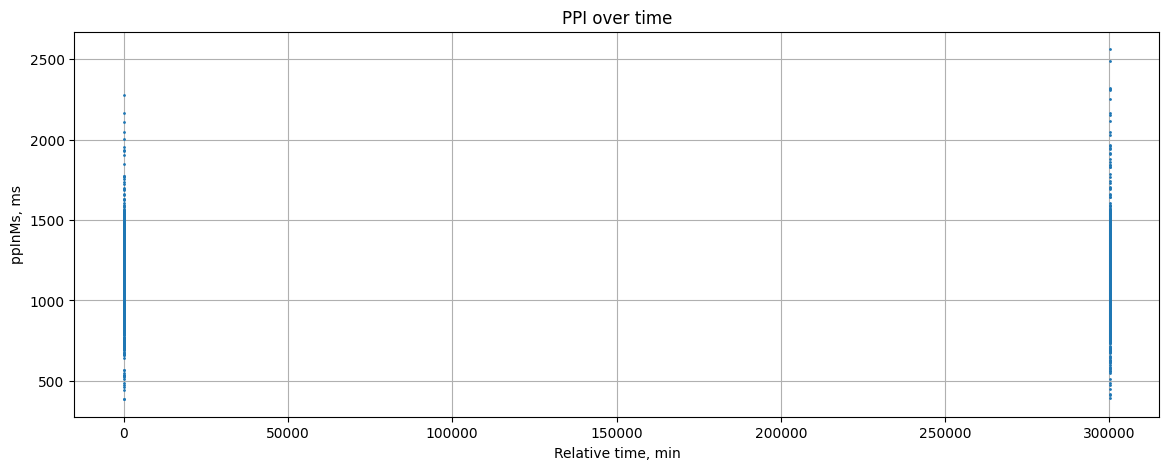

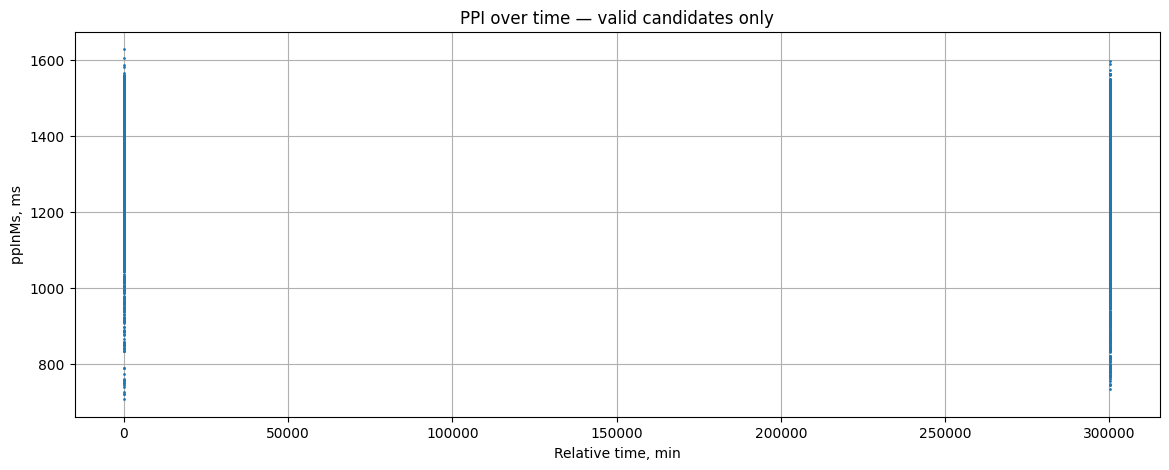

In [15]:
# === 12. Plot: PPI over relative time ===

plt.figure(figsize=(14, 5))
plt.plot(df_sorted["t_rel_min"], df_sorted["ppInMs"], marker=".", linestyle="none", markersize=2)
plt.xlabel("Relative time, min")
plt.ylabel("ppInMs, ms")
plt.title("PPI over time")
plt.show()

# Valid-only overlay as separate chart
valid_df = df_sorted[df_sorted["is_valid_candidate"]].copy()
plt.figure(figsize=(14, 5))
plt.plot(valid_df["t_rel_min"], valid_df["ppInMs"], marker=".", linestyle="none", markersize=2)
plt.xlabel("Relative time, min")
plt.ylabel("ppInMs, ms")
plt.title("PPI over time — valid candidates only")
plt.show()


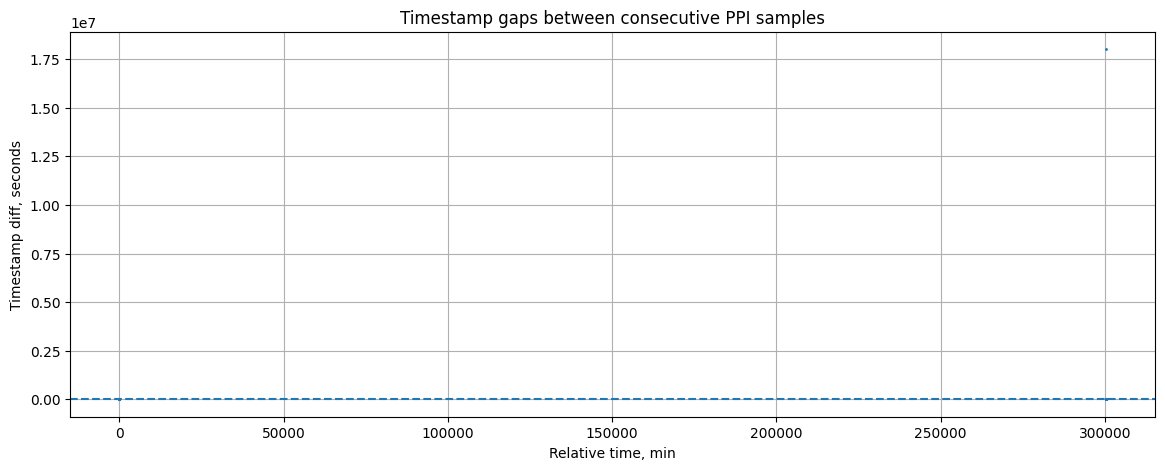

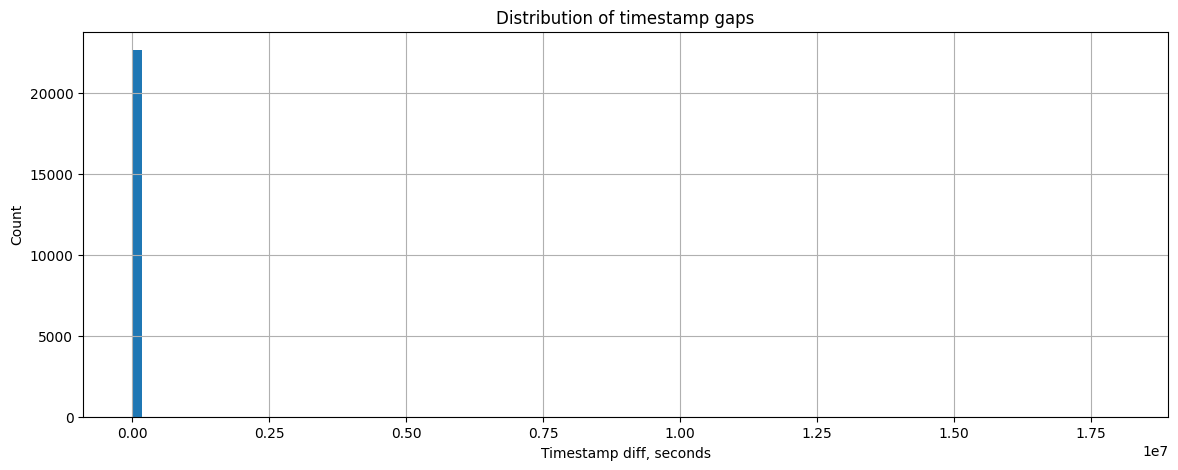

In [25]:
# === 13. Plot: timestamp gaps ===
valid_df = df_sorted[df_sorted["is_valid_candidate"]].copy()

plt.figure(figsize=(14, 5))
# plt.plot(df_sorted["t_rel_min"], df_sorted["timestamp_diff_s_if_ns"], marker=".", linestyle="none", markersize=2)
plt.plot(valid_df["t_rel_min"], valid_df["timestamp_diff_s_if_ns"], marker=".", linestyle="none", markersize=2)
plt.axhline(GAP_THRESHOLD_S, linestyle="--")
plt.xlabel("Relative time, min")
plt.ylabel("Timestamp diff, seconds")
plt.title("Timestamp gaps between consecutive PPI samples")
plt.show()

plt.figure(figsize=(14, 5))
plt.hist(valid_df["timestamp_diff_s_if_ns"].dropna(), bins=100)
plt.xlabel("Timestamp diff, seconds")
plt.ylabel("Count")
plt.title("Distribution of timestamp gaps")
plt.show()


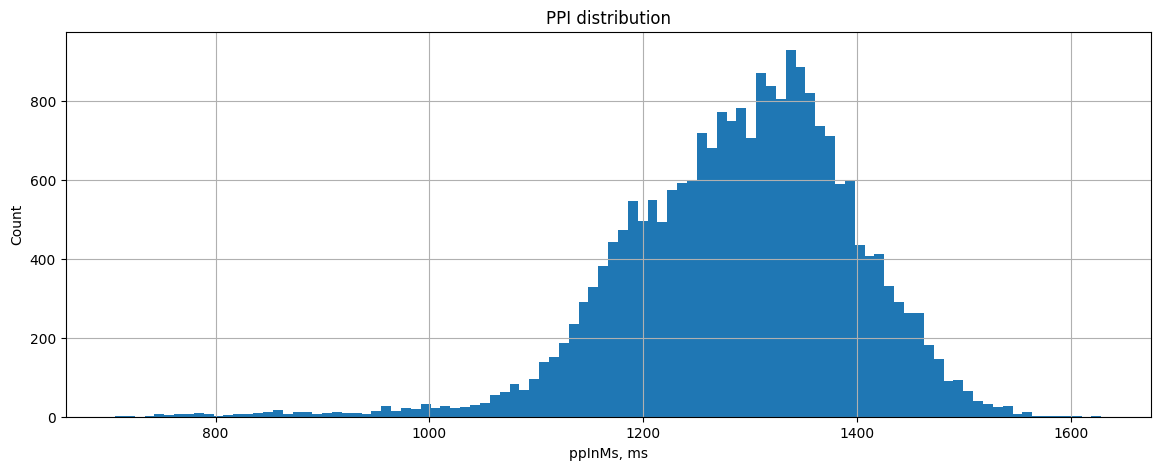

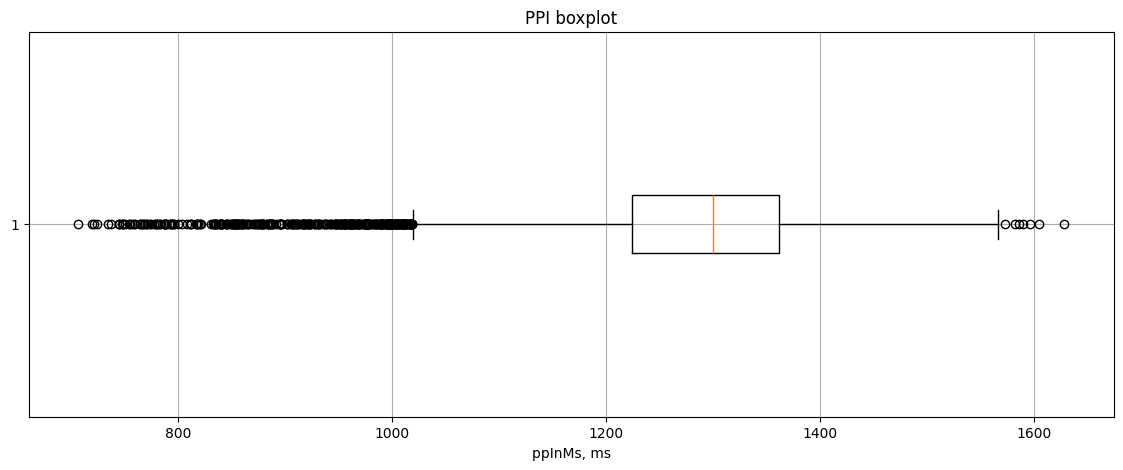

In [26]:
# === 14. Plot: PPI distribution and outliers ===
valid_df = df_sorted[df_sorted["is_valid_candidate"]].copy()

plt.figure(figsize=(14, 5))
plt.hist(valid_df["ppInMs"].dropna(), bins=100)
plt.xlabel("ppInMs, ms")
plt.ylabel("Count")
plt.title("PPI distribution")
plt.show()

plt.figure(figsize=(14, 5))
plt.boxplot(valid_df["ppInMs"].dropna(), vert=False)
plt.xlabel("ppInMs, ms")
plt.title("PPI boxplot")
plt.show()


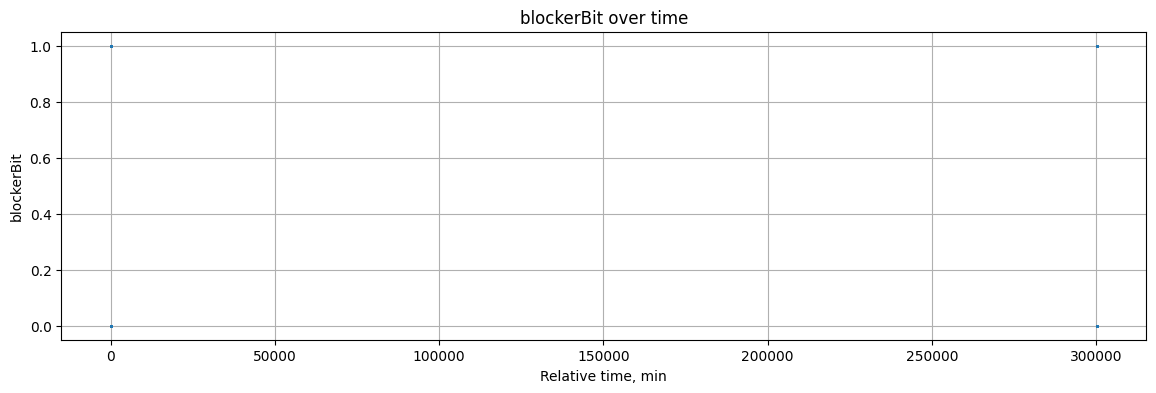

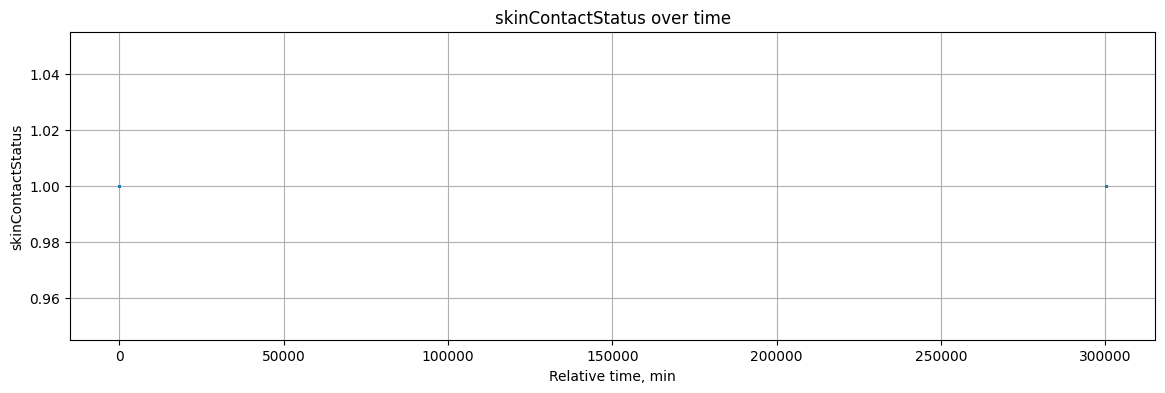

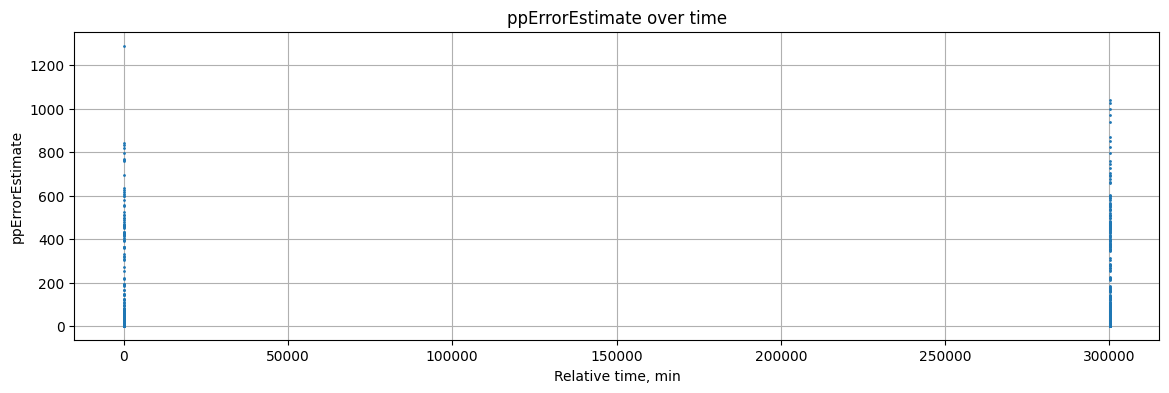

In [18]:
# === 15. Plot: quality flags over time ===

flag_plot_cols = ["blockerBit", "skinContactStatus", "ppErrorEstimate"]

for col in flag_plot_cols:
    plt.figure(figsize=(14, 4))
    plt.plot(df_sorted["t_rel_min"], df_sorted[col], marker=".", linestyle="none", markersize=2)
    plt.xlabel("Relative time, min")
    plt.ylabel(col)
    plt.title(f"{col} over time")
    plt.show()


,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
hr,23660.0,46.664920,4.950968,0.000000,40.000000,41.000000,44.000000,46.000000,49.000000,53.000000,60.000000,81.000000
hr_from_ppi,23660.0,47.503763,6.218327,23.410066,39.829798,41.407867,44.117647,46.332046,49.423394,56.497175,71.891612,155.844156
ppInMs,23660.0,1279.231910,130.715084,385.000000,834.590000,1062.000000,1214.000000,1295.000000,1360.000000,1449.000000,1506.410000,2563.000000


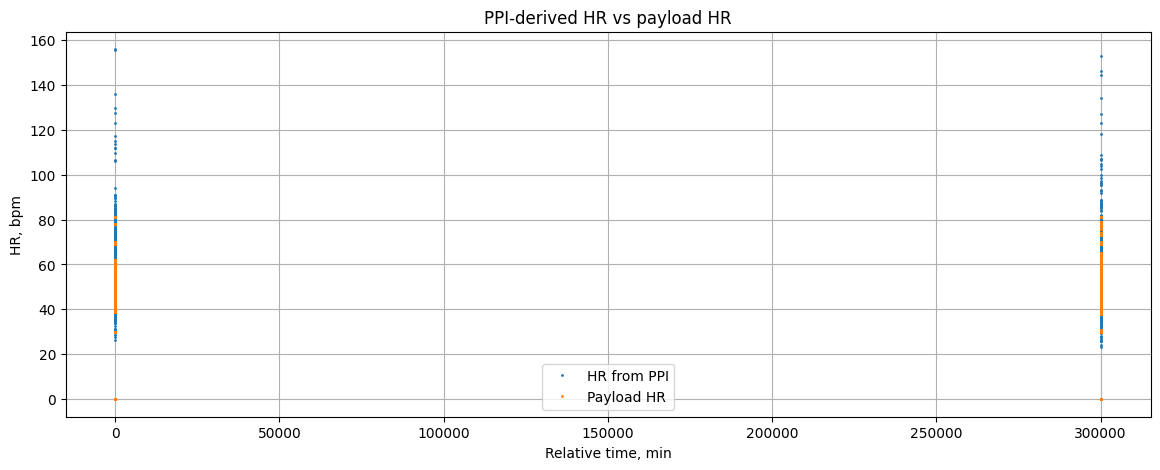

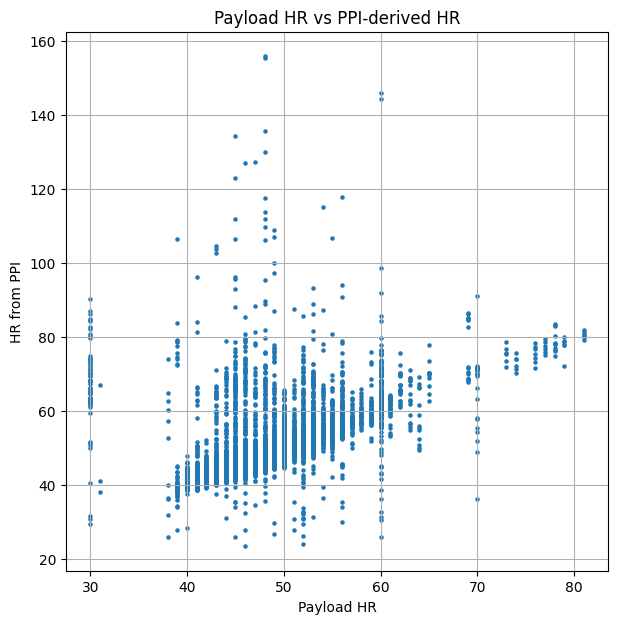

In [19]:
# === 16. Plot: PPI-derived HR vs payload HR ===

# PPI-derived HR: 60_000 / ppInMs
df_sorted["hr_from_ppi"] = 60000.0 / df_sorted["ppInMs"]

display(df_sorted[["hr", "hr_from_ppi", "ppInMs", "is_valid_candidate"]].describe(percentiles=[.01, .05, .25, .5, .75, .95, .99]).T)

plt.figure(figsize=(14, 5))
plt.plot(df_sorted["t_rel_min"], df_sorted["hr_from_ppi"], marker=".", linestyle="none", markersize=2, label="HR from PPI")
plt.plot(df_sorted["t_rel_min"], df_sorted["hr"], marker=".", linestyle="none", markersize=2, label="Payload HR")
plt.xlabel("Relative time, min")
plt.ylabel("HR, bpm")
plt.title("PPI-derived HR vs payload HR")
plt.legend()
plt.show()

# Scatter only where payload HR > 0
hr_cmp = df_sorted[(df_sorted["hr"] > 0) & df_sorted["hr_from_ppi"].notna()].copy()
if len(hr_cmp):
    plt.figure(figsize=(7, 7))
    plt.scatter(hr_cmp["hr"], hr_cmp["hr_from_ppi"], s=5)
    plt.xlabel("Payload HR")
    plt.ylabel("HR from PPI")
    plt.title("Payload HR vs PPI-derived HR")
    plt.show()
else:
    print("No payload HR > 0 samples found. This can be normal for some offline PPI exports or low-quality segments.")


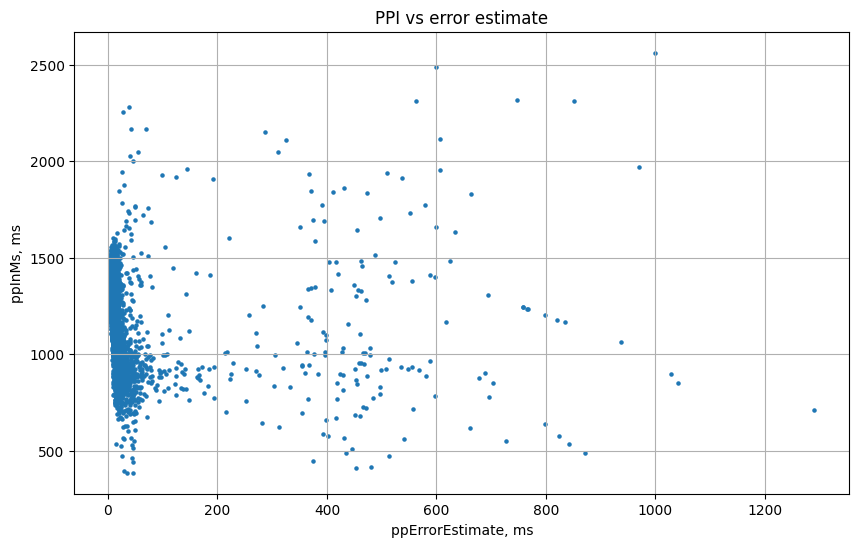

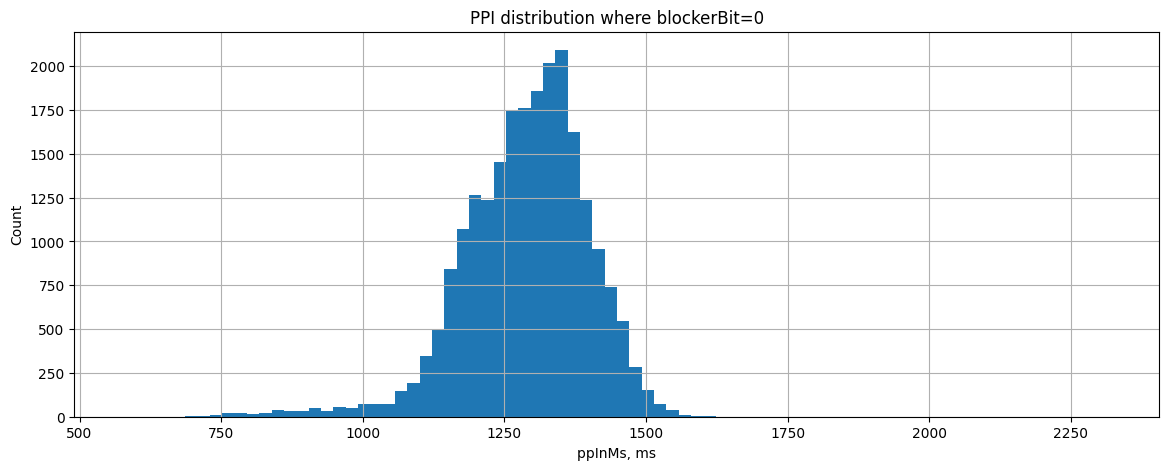

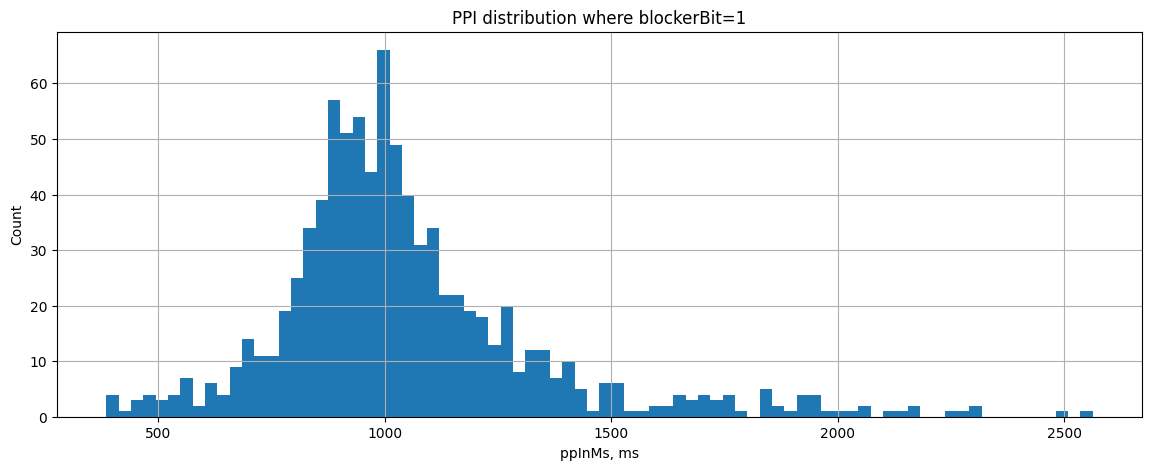

In [20]:
# === 17. Plot: ppErrorEstimate vs PPI ===

plt.figure(figsize=(10, 6))
plt.scatter(df_sorted["ppErrorEstimate"], df_sorted["ppInMs"], s=5)
plt.xlabel("ppErrorEstimate, ms")
plt.ylabel("ppInMs, ms")
plt.title("PPI vs error estimate")
plt.show()

# Compare PPI distribution by blockerBit
for flag_value in sorted(df_sorted["blockerBit"].dropna().unique()):
    subset = df_sorted[df_sorted["blockerBit"] == flag_value]["ppInMs"].dropna()
    if len(subset):
        plt.figure(figsize=(14, 5))
        plt.hist(subset, bins=80)
        plt.xlabel("ppInMs, ms")
        plt.ylabel("Count")
        plt.title(f"PPI distribution where blockerBit={flag_value}")
        plt.show()


## 7. Window features для ML / sleep detection

Для ML або deterministic sleep pipeline краще працювати не з raw samples напряму, а з window-level features:

- valid sample count;
- valid ratio;
- blocker ratio;
- contact loss ratio;
- gap count;
- mean/median PPI;
- SDNN;
- RMSSD;
- pNN50;
- HR from PPI stats;
- ppError stats.

Нижче будуємо 30s, 60s, 5m windows по `t_rel_s`.


In [21]:
# === 18. HRV / PPI feature helpers ===

def rmssd(values_ms: pd.Series) -> float:
    x = pd.to_numeric(values_ms, errors="coerce").dropna().to_numpy()
    if len(x) < 2:
        return np.nan
    diffs = np.diff(x)
    return float(np.sqrt(np.mean(diffs ** 2)))

def pnn50(values_ms: pd.Series) -> float:
    x = pd.to_numeric(values_ms, errors="coerce").dropna().to_numpy()
    if len(x) < 2:
        return np.nan
    diffs = np.abs(np.diff(x))
    return float(np.mean(diffs > 50))

def sdnn(values_ms: pd.Series) -> float:
    x = pd.to_numeric(values_ms, errors="coerce").dropna().to_numpy()
    if len(x) < 2:
        return np.nan
    return float(np.std(x, ddof=1))

def build_window_features(samples: pd.DataFrame, window_s: int) -> pd.DataFrame:
    d = samples.copy()
    d = d[d["t_rel_s"].notna()].copy()
    d["window_s"] = window_s
    d["window_index"] = np.floor(d["t_rel_s"] / window_s).astype(int)
    d["window_start_s"] = d["window_index"] * window_s
    d["window_start_min"] = d["window_start_s"] / 60.0

    grouped = d.groupby("window_index", dropna=False)

    rows = []
    for idx, g in grouped:
        valid = g[g["is_valid_candidate"]].copy()
        row = {
            "window_s": window_s,
            "window_index": int(idx),
            "window_start_s": float(idx * window_s),
            "window_start_min": float(idx * window_s / 60),
            "sample_count": int(len(g)),
            "valid_count": int(len(valid)),
            "valid_ratio": float(len(valid) / len(g)) if len(g) else np.nan,
            "blocker_ratio": float((g["blockerBit"] == 1).mean()) if len(g) else np.nan,
            "contact_loss_ratio": float((g["skinContactStatus"] == 0).mean()) if len(g) else np.nan,
            "gap_gt_threshold_count": int(g["gap_gt_threshold"].sum()) if "gap_gt_threshold" in g else 0,
            "pp_ms_mean": float(valid["ppInMs"].mean()) if len(valid) else np.nan,
            "pp_ms_median": float(valid["ppInMs"].median()) if len(valid) else np.nan,
            "pp_ms_std": float(valid["ppInMs"].std(ddof=1)) if len(valid) > 1 else np.nan,
            "pp_ms_min": float(valid["ppInMs"].min()) if len(valid) else np.nan,
            "pp_ms_max": float(valid["ppInMs"].max()) if len(valid) else np.nan,
            "sdnn_ms": sdnn(valid["ppInMs"]),
            "rmssd_ms": rmssd(valid["ppInMs"]),
            "pnn50": pnn50(valid["ppInMs"]),
            "hr_from_ppi_mean": float(valid["hr_from_ppi"].mean()) if len(valid) else np.nan,
            "hr_from_ppi_median": float(valid["hr_from_ppi"].median()) if len(valid) else np.nan,
            "pp_error_mean": float(g["ppErrorEstimate"].mean()) if len(g) else np.nan,
            "pp_error_median": float(g["ppErrorEstimate"].median()) if len(g) else np.nan,
            "pp_error_max": float(g["ppErrorEstimate"].max()) if len(g) else np.nan,
        }
        rows.append(row)

    return pd.DataFrame(rows).sort_values("window_index").reset_index(drop=True)


features_30s = build_window_features(df_sorted, 30)
features_60s = build_window_features(df_sorted, 60)
features_5m = build_window_features(df_sorted, 300)

print("30s windows:", features_30s.shape)
print("60s windows:", features_60s.shape)
print("5m windows:", features_5m.shape)

display(features_30s.head())
display(features_60s.head())
display(features_5m.head())


30s windows: (4, 23)
60s windows: (3, 23)
5m windows: (2, 23)


,window_s,window_index,window_start_s,window_start_min,sample_count,valid_count,valid_ratio,blocker_ratio,contact_loss_ratio,gap_gt_threshold_count,pp_ms_mean,pp_ms_median,pp_ms_std,pp_ms_min,pp_ms_max,sdnn_ms,rmssd_ms,pnn50,hr_from_ppi_mean,hr_from_ppi_median,pp_error_mean,pp_error_median,pp_error_max
0,30,0,0.0,0.0,7732,7399,0.956932,0.036472,0.0,0,1292.666306,1302.0,104.723644,706.0,1628.0,104.723644,40.206755,0.121249,46.751969,46.082949,15.149509,10.0,1290.0
1,30,600477,18014310.0,300238.5,124,124,1.000000,0.000000,0.0,1,1408.887097,1415.0,61.939022,1152.0,1561.0,61.939022,83.560698,0.528455,42.672367,42.402827,8.854839,9.0,16.0
2,30,600478,18014340.0,300239.0,7500,7250,0.966667,0.028267,0.0,0,1292.603448,1304.0,104.941594,734.0,1563.0,104.941594,146.686612,0.702304,46.757875,46.012270,14.015467,10.0,999.0
3,30,600479,18014370.0,300239.5,8304,7884,0.949422,0.044436,0.0,0,1282.744673,1293.0,109.387392,744.0,1596.0,109.387392,143.341197,0.610935,47.154130,46.403712,15.221098,10.0,1041.0


,window_s,window_index,window_start_s,window_start_min,sample_count,valid_count,valid_ratio,blocker_ratio,contact_loss_ratio,gap_gt_threshold_count,pp_ms_mean,pp_ms_median,pp_ms_std,pp_ms_min,pp_ms_max,sdnn_ms,rmssd_ms,pnn50,hr_from_ppi_mean,hr_from_ppi_median,pp_error_mean,pp_error_median,pp_error_max
0,60,0,0.0,0.0,7732,7399,0.956932,0.036472,0.0,0,1292.666306,1302.0,104.723644,706.0,1628.0,104.723644,40.206755,0.121249,46.751969,46.082949,15.149509,10.0,1290.0
1,60,300238,18014280.0,300238.0,124,124,1.000000,0.000000,0.0,1,1408.887097,1415.0,61.939022,1152.0,1561.0,61.939022,83.560698,0.528455,42.672367,42.402827,8.854839,9.0,16.0
2,60,300239,18014340.0,300239.0,15804,15134,0.957606,0.036763,0.0,0,1287.467556,1298.0,107.390077,734.0,1596.0,107.390077,144.949069,0.654662,46.964303,46.224961,14.648950,10.0,1041.0


,window_s,window_index,window_start_s,window_start_min,sample_count,valid_count,valid_ratio,blocker_ratio,contact_loss_ratio,gap_gt_threshold_count,pp_ms_mean,pp_ms_median,pp_ms_std,pp_ms_min,pp_ms_max,sdnn_ms,rmssd_ms,pnn50,hr_from_ppi_mean,hr_from_ppi_median,pp_error_mean,pp_error_median,pp_error_max
0,300,0,0.0,0.0,7732,7399,0.956932,0.036472,0.0,0,1292.666306,1302.0,104.723644,706.0,1628.0,104.723644,40.206755,0.121249,46.751969,46.082949,15.149509,10.0,1290.0
1,300,60047,18014100.0,300235.0,15928,15258,0.957936,0.036477,0.0,1,1288.454319,1299.0,107.650701,734.0,1596.0,107.650701,144.554219,0.653602,46.929423,46.189376,14.603842,10.0,1041.0


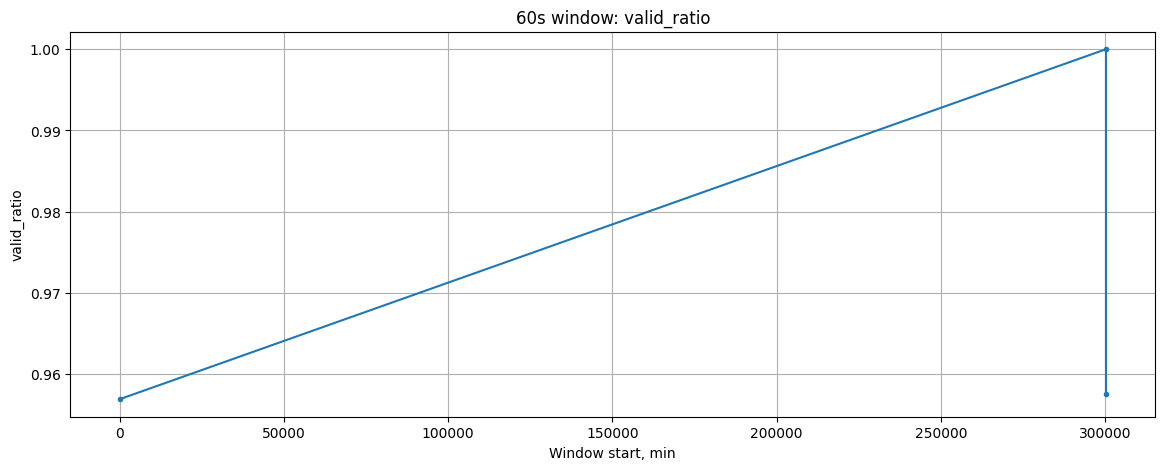

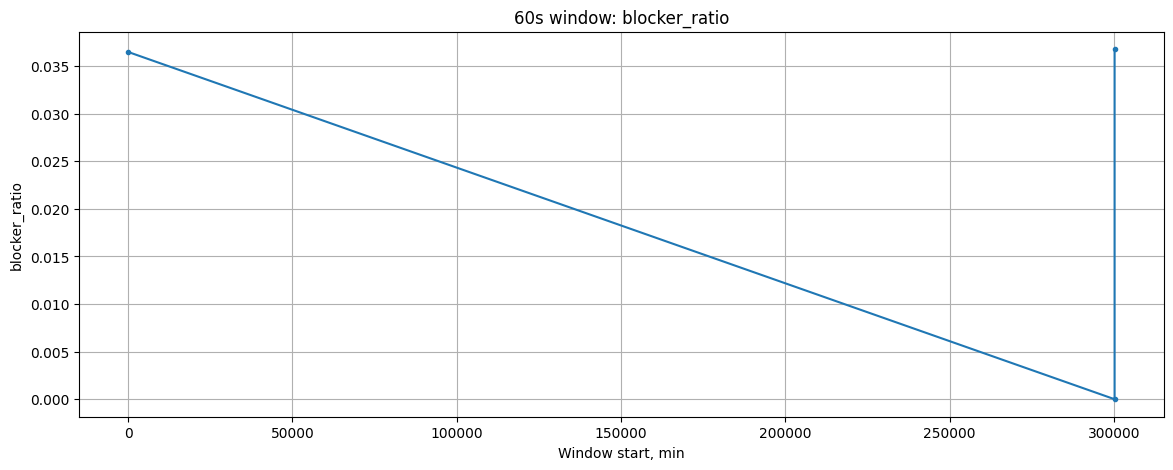

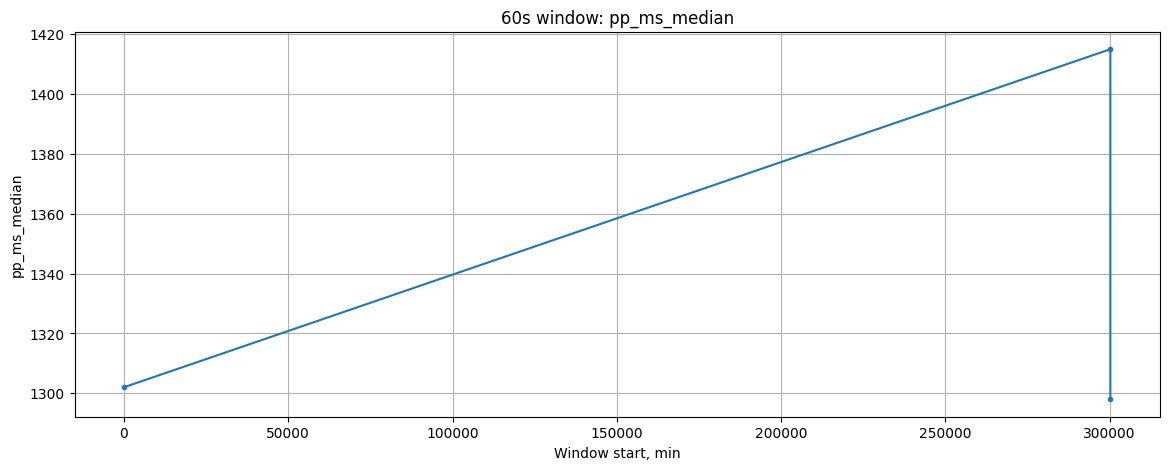

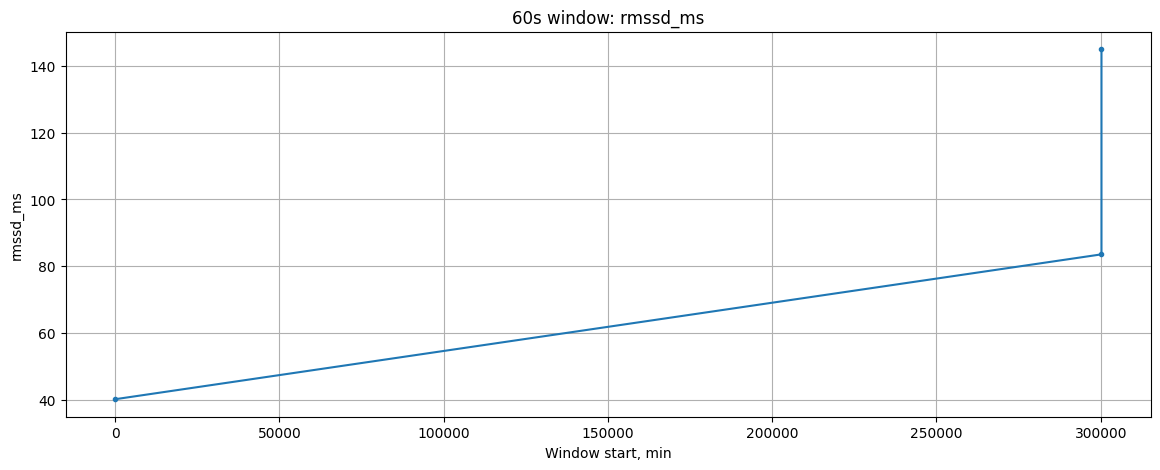

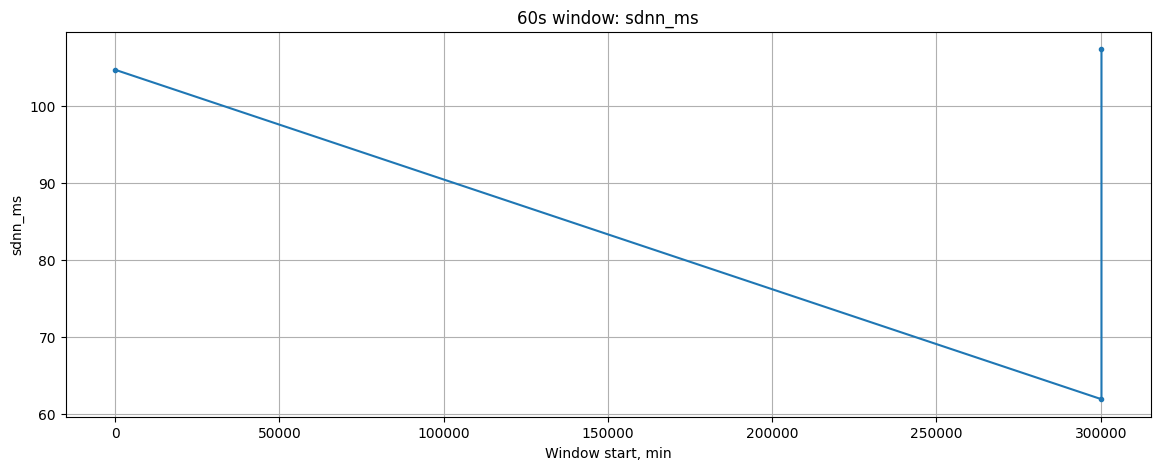

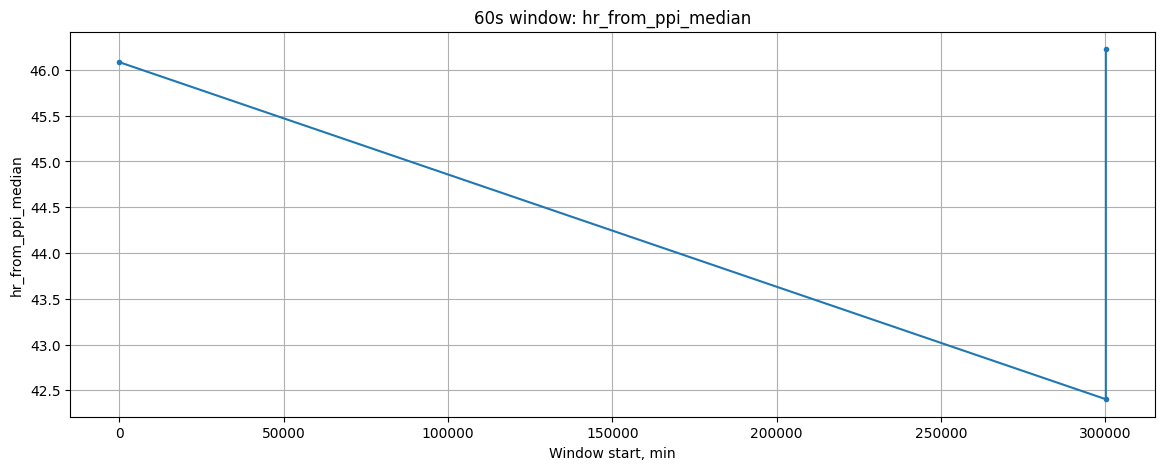

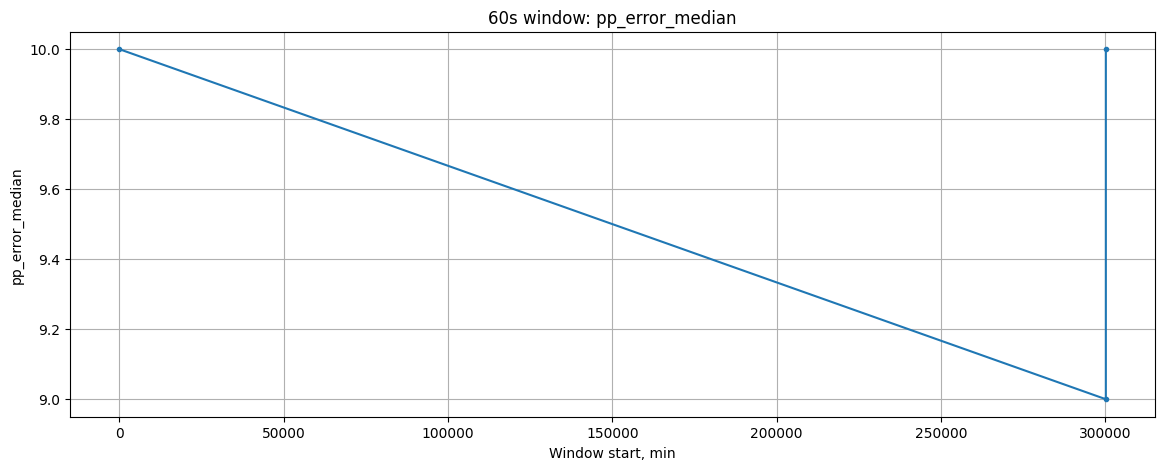

In [22]:
# === 19. Plot window features ===

def plot_window_feature(features: pd.DataFrame, col: str, title: Optional[str] = None):
    if col not in features.columns:
        print(f"Missing column: {col}")
        return
    plt.figure(figsize=(14, 5))
    plt.plot(features["window_start_min"], features[col], marker=".", linestyle="-")
    plt.xlabel("Window start, min")
    plt.ylabel(col)
    plt.title(title or f"{col} over time")
    plt.show()

for feature_col in ["valid_ratio", "blocker_ratio", "pp_ms_median", "rmssd_ms", "sdnn_ms", "hr_from_ppi_median", "pp_error_median"]:
    plot_window_feature(features_60s, feature_col, f"60s window: {feature_col}")


## 8. Автоматичний EDA report summary

Ця секція збирає короткий summary, який можна використати для `ppi_quality_summary.json` або як основу для CP15 quality diagnostics.


In [23]:
# === 20. EDA summary artifact ===

def safe_float(x):
    if pd.isna(x):
        return None
    return float(x)

eda_summary = {
    "file": str(JSONL_PATH),
    "chunks": int(len(chunks_df)),
    "samples": int(len(df_sorted)),
    "session_id": df_sorted["session_id"].dropna().iloc[0] if len(df_sorted["session_id"].dropna()) else None,
    "stream_id": df_sorted["stream_id"].dropna().iloc[0] if len(df_sorted["stream_id"].dropna()) else None,
    "source": {
        "vendor": df_sorted["vendor"].dropna().iloc[0] if len(df_sorted["vendor"].dropna()) else None,
        "device_model": df_sorted["device_model"].dropna().iloc[0] if len(df_sorted["device_model"].dropna()) else None,
        "device_id": df_sorted["device_id"].dropna().iloc[0] if len(df_sorted["device_id"].dropna()) else None,
        "collection_mode": df_sorted["collection_mode"].dropna().iloc[0] if len(df_sorted["collection_mode"].dropna()) else None,
    },
    "relative_duration_s": safe_float(duration_s),
    "sequence": {
        "min": int(seq.min()) if len(seq) else None,
        "max": int(seq.max()) if len(seq) else None,
        "missing_count": int(len(missing_seq)),
        "duplicate_count": int(len(duplicate_seq)),
    },
    "timestamps": {
        "monotonic_non_decreasing": bool(df_sorted["is_timestamp_monotonic_non_decreasing"].all()),
        "duplicate_timestamp_count": int(df_sorted["is_duplicate_timestamp"].sum()),
        "negative_diff_count": int((df_sorted["timestamp_diff_raw"] < 0).sum()),
        "gap_threshold_s": GAP_THRESHOLD_S,
        "gap_gt_threshold_count": int(df_sorted["gap_gt_threshold"].sum()),
        "median_timestamp_diff_s_if_ns": safe_float(df_sorted["timestamp_diff_s_if_ns"].median()),
        "p95_timestamp_diff_s_if_ns": safe_float(df_sorted["timestamp_diff_s_if_ns"].quantile(0.95)),
        "p99_timestamp_diff_s_if_ns": safe_float(df_sorted["timestamp_diff_s_if_ns"].quantile(0.99)),
    },
    "quality": {
        "valid_candidate_ratio": safe_float(df_sorted["is_valid_candidate"].mean()),
        "blocker_ratio": safe_float((df_sorted["blockerBit"] == 1).mean()),
        "contact_loss_ratio": safe_float((df_sorted["skinContactStatus"] == 0).mean()),
        "pp_error_mean": safe_float(df_sorted["ppErrorEstimate"].mean()),
        "pp_error_median": safe_float(df_sorted["ppErrorEstimate"].median()),
        "pp_error_p95": safe_float(df_sorted["ppErrorEstimate"].quantile(0.95)),
    },
    "ppi": {
        "pp_min_ms": safe_float(df_sorted["ppInMs"].min()),
        "pp_median_ms": safe_float(df_sorted["ppInMs"].median()),
        "pp_mean_ms": safe_float(df_sorted["ppInMs"].mean()),
        "pp_max_ms": safe_float(df_sorted["ppInMs"].max()),
        "physio_plausible_ratio": safe_float(df_sorted["ppi_physio_plausible"].mean()),
    },
    "hr": {
        "payload_hr_zero_ratio": safe_float((df_sorted["hr"] == 0).mean()),
        "payload_hr_nonzero_count": int((df_sorted["hr"] > 0).sum()),
        "hr_from_ppi_median": safe_float(df_sorted["hr_from_ppi"].median()),
        "hr_from_ppi_mean": safe_float(df_sorted["hr_from_ppi"].mean()),
    },
}

print(json.dumps(eda_summary, indent=2, ensure_ascii=False))


{
  "file": "notebooks/data_cache/session_id=a3b4f7a4-c810-4e7a-8152-e9a05dd32b1e/data/wearable/raw/user_id=2/source=polar_verity_sense/date=2026-05-06/session_id=a3b4f7a4-c810-4e7a-8152-e9a05dd32b1e/streams/ppi/chunks.jsonl",
  "chunks": 1,
  "samples": 23660,
  "session_id": "a3b4f7a4-c810-4e7a-8152-e9a05dd32b1e",
  "stream_id": "stream-offline-ppi-a3b4f7a4-c810-4e7a-8152-e9a05dd32b1e",
  "source": {
    "vendor": "polar",
    "device_model": "verity_sense",
    "device_id": "06EDBA31",
    "collection_mode": "offline_recording"
  },
  "relative_duration_s": 18014398.509481985,
  "sequence": {
    "min": 1,
    "max": 1,
    "missing_count": 0,
    "duplicate_count": 0
  },
  "timestamps": {
    "monotonic_non_decreasing": true,
    "duplicate_timestamp_count": 12040,
    "negative_diff_count": 0,
    "gap_threshold_s": 5.0,
    "gap_gt_threshold_count": 1,
    "median_timestamp_diff_s_if_ns": 0.001,
    "p95_timestamp_diff_s_if_ns": 0.01,
    "p99_timestamp_diff_s_if_ns": 0.018
  },

In [24]:
# === 21. Optional: save processed EDA outputs near notebook working directory ===

OUTPUT_DIR = Path("ppi_eda_outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

samples_csv = OUTPUT_DIR / "ppi_samples_flat.csv"
features_30s_csv = OUTPUT_DIR / "ppi_features_30s.csv"
features_60s_csv = OUTPUT_DIR / "ppi_features_60s.csv"
features_5m_csv = OUTPUT_DIR / "ppi_features_5m.csv"
summary_json = OUTPUT_DIR / "ppi_eda_summary.json"

df_sorted.to_csv(samples_csv, index=False)
features_30s.to_csv(features_30s_csv, index=False)
features_60s.to_csv(features_60s_csv, index=False)
features_5m.to_csv(features_5m_csv, index=False)

with summary_json.open("w", encoding="utf-8") as f:
    json.dump(eda_summary, f, indent=2, ensure_ascii=False)

print("Saved:")
for p in [samples_csv, features_30s_csv, features_60s_csv, features_5m_csv, summary_json]:
    print("-", p)


Saved:
- ppi_eda_outputs/ppi_samples_flat.csv
- ppi_eda_outputs/ppi_features_30s.csv
- ppi_eda_outputs/ppi_features_60s.csv
- ppi_eda_outputs/ppi_features_5m.csv
- ppi_eda_outputs/ppi_eda_summary.json


## 9. Як читати результат

### Для gap analysis

Дивись:

- `timestamp_diff_s_if_ns`;
- `gap_gt_threshold`;
- histogram timestamp gaps;
- windows із `gap_gt_threshold_count > 0`.

### Для якості PPI

Дивись:

- `blockerBit`;
- `skinContactStatus`;
- `ppErrorEstimate`;
- `valid_ratio`;
- `blocker_ratio`;
- `contact_loss_ratio`.

### Для ML feature readiness

Мінімально корисні features:

- `pp_ms_median`;
- `rmssd_ms`;
- `sdnn_ms`;
- `pnn50`;
- `hr_from_ppi_median`;
- `valid_ratio`;
- `blocker_ratio`;
- `pp_error_median`;
- `gap_gt_threshold_count`.

### Що не варто робити

- Не перезаписувати raw JSONL.
- Не вважати `timeStamp` автоматично canonical UTC.
- Не будувати sleep/stage inference до quality diagnostics.
- Не використовувати samples з `blockerBit=1` як рівноцінні clean PPI без окремого confidence/quality маркування.
